In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/mos2'

import glob
for f in sorted(glob.glob(DATA_DIR + '/*.txt')):
    print(f.split('/')[-1])

Mounted at /content/drive
11.04 si02 0W pl.txt
11.04 si02 0W raman.txt
11.04 si02 10W pl.txt
11.04 si02 10W raman.txt
11.04 si02 20W pl.txt
11.04 si02 20W raman.txt
11.04 si02 30W pl.txt
11.04 si02 30W raman.txt
11.04 si02 40W pl.txt
11.04 si02 40W raman.txt
11.04 si02 50W pl.txt
11.04 si02 50W raman 2.txt
11.04 si02 50W raman.txt
11.04 si02 60W pl.txt
11.04 si02 60W raman 1.txt
11.04 si02 60W raman 2.txt
11.04 si02 60W raman 3.txt
11.04 si02 70W pl.txt
11.04 si02 70W raman.txt


In [4]:
import numpy as np, pandas as pd, re, os, glob
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

trapz = getattr(np, "trapezoid", np.trapz)

def lorentzian(x, amp, cen, wid):
    return amp * wid**2 / ((x - cen)**2 + wid**2)

def multi_lorentzian(x, *p):
    y = np.zeros_like(x)
    for i in range(0, len(p), 3):
        y += lorentzian(x, *p[i:i+3])
    return y

def local_baseline(xs, ys):
    e = max(3, len(xs)//25)
    x0, y0 = xs[:e].mean(), ys[:e].mean()
    x1, y1 = xs[-e:].mean(), ys[-e:].mean()
    return ys - (y0 + (y1-y0)*(xs-x0)/(x1-x0))

def fit_peaks(x, y, centers, window, wid0=4.0, tol=6.0, wmax=25.0):
    m = (x >= window[0]) & (x <= window[1])
    xs, ys = x[m], local_baseline(x[m], y[m])
    p0, lo, hi = [], [], []
    for c in centers:
        p0 += [max(ys.max()*0.3, 1.0), c, wid0]
        lo += [0.0, c-tol, 1.0]
        hi += [np.inf, c+tol, wmax]
    popt, _ = curve_fit(multi_lorentzian, xs, ys, p0=p0,
                        bounds=(lo, hi), maxfev=60000)
    peaks = [dict(cen=popt[i+1], wid=popt[i+2],
                  area=np.pi*popt[i]*popt[i+2]) for i in range(0, len(popt), 3)]
    return sorted(peaks, key=lambda d: d['cen'])

def parse_power(path):
    return int(re.search(r'(\d+)\s*W', os.path.basename(path)).group(1))

def is_repeat(path):
    return False    # 반복 측정도 전부 사용, 나중에 평균 처리

print("준비 완료")

준비 완료


In [5]:
for f in sorted(glob.glob(DATA_DIR + '/*raman*.txt')):
    name = os.path.basename(f)
    try:
        print(f"{name:35s} -> {parse_power(f):3d} W   반복={is_repeat(f)}")
    except:
        print(f"{name:35s} -> 인식 실패")

11.04 si02 0W raman.txt             ->   0 W   반복=False
11.04 si02 10W raman.txt            ->  10 W   반복=False
11.04 si02 20W raman.txt            ->  20 W   반복=False
11.04 si02 30W raman.txt            ->  30 W   반복=False
11.04 si02 40W raman.txt            ->  40 W   반복=False
11.04 si02 50W raman 2.txt          ->  50 W   반복=False
11.04 si02 50W raman.txt            ->  50 W   반복=False
11.04 si02 60W raman 1.txt          ->  60 W   반복=False
11.04 si02 60W raman 2.txt          ->  60 W   반복=False
11.04 si02 60W raman 3.txt          ->  60 W   반복=False
11.04 si02 70W raman.txt            ->  70 W   반복=False


In [6]:
rows = []
for f in sorted(glob.glob(DATA_DIR + '/*raman*.txt'), key=parse_power):
    a = np.loadtxt(f)
    x, y = a[:,0], savgol_filter(a[:,1], 11, 3)

    si = fit_peaks(x, y, [520.7], (505,540), 3.0, 4.0, 15.0)[0]
    e2g_p, e2g_m, a1g = fit_peaks(x, y, [379,386,405], (358,432), 3.5, 6.0, 20.0)

    rows.append(dict(
        power_W    = parse_power(f),
        E2g_split  = e2g_m['cen'] - e2g_p['cen'],
        A1g_center = a1g['cen'],
        A1g_norm   = a1g['area'] / si['area'],
        E2g_norm   = (e2g_p['area'] + e2g_m['area']) / si['area'],
        Si_area    = si['area'],
    ))

raman_all = pd.DataFrame(rows)
print("=== 개별 측정 (반복 포함) ===")
print(raman_all.round(3).to_string(index=False))

=== 개별 측정 (반복 포함) ===
 power_W  E2g_split  A1g_center  A1g_norm  E2g_norm   Si_area
       0      2.046     404.361     0.495     0.315 15355.320
      10      1.998     404.983     0.323     0.202 15624.327
      20      2.311     404.848     0.313     0.198 15814.612
      30      2.784     404.916     0.295     0.190 14714.290
      40      5.671     404.751     0.260     0.171 14729.293
      50      9.824     404.273     0.316     0.180 14397.051
      50     10.159     404.343     0.327     0.187 14281.211
      60      9.956     405.515     0.178     0.085 14798.440
      60      9.442     406.227     0.135     0.058 15141.991
      60     10.461     406.071     0.151     0.072 14828.513
      70      9.576     405.176     0.164     0.060 14261.070


In [7]:
raman = raman_all.groupby('power_W').mean().reset_index()
raman['E2g_split_std'] = raman_all.groupby('power_W')['E2g_split'].std().values
raman['n'] = raman_all.groupby('power_W').size().values

print("=== 파워별 평균 ===")
print(raman[['power_W','n','E2g_split','E2g_split_std','A1g_norm','E2g_norm']].round(3).to_string(index=False))

=== 파워별 평균 ===
 power_W  n  E2g_split  E2g_split_std  A1g_norm  E2g_norm
       0  1      2.046            NaN     0.495     0.315
      10  1      1.998            NaN     0.323     0.202
      20  1      2.311            NaN     0.313     0.198
      30  1      2.784            NaN     0.295     0.190
      40  1      5.671            NaN     0.260     0.171
      50  2      9.992          0.237     0.321     0.184
      60  3      9.953          0.510     0.155     0.071
      70  1      9.576            NaN     0.164     0.060


In [8]:
rows = []
for f in sorted(glob.glob(DATA_DIR + '/*pl*.txt'), key=parse_power):
    a = np.loadtxt(f)
    x = a[:,0]
    y = savgol_filter(a[:,1], 31, 3)
    m = (x > 640) & (x < 720)
    xs = x[m]
    ys = local_baseline(x[m], y[m])
    rows.append(dict(power_W=parse_power(f),
                     PL_area=trapz(ys, xs),
                     PL_lambda=xs[ys.argmax()]))

pl = pd.DataFrame(rows).groupby('power_W').mean().reset_index()
pl['PL_rel'] = pl.PL_area / pl.PL_area.iloc[0]

merged = raman.merge(pl, on='power_W')
print(merged[['power_W','n','E2g_split','E2g_split_std','PL_rel']].round(4).to_string(index=False))

 power_W  n  E2g_split  E2g_split_std  PL_rel
       0  1     2.0462            NaN  1.0000
      10  1     1.9978            NaN  0.3530
      20  1     2.3112            NaN  0.1252
      30  1     2.7837            NaN  0.0816
      40  1     5.6710            NaN  0.0762
      50  2     9.9915         0.2367  0.0150
      60  3     9.9530         0.5095  0.0003
      70  1     9.5758            NaN  0.0010


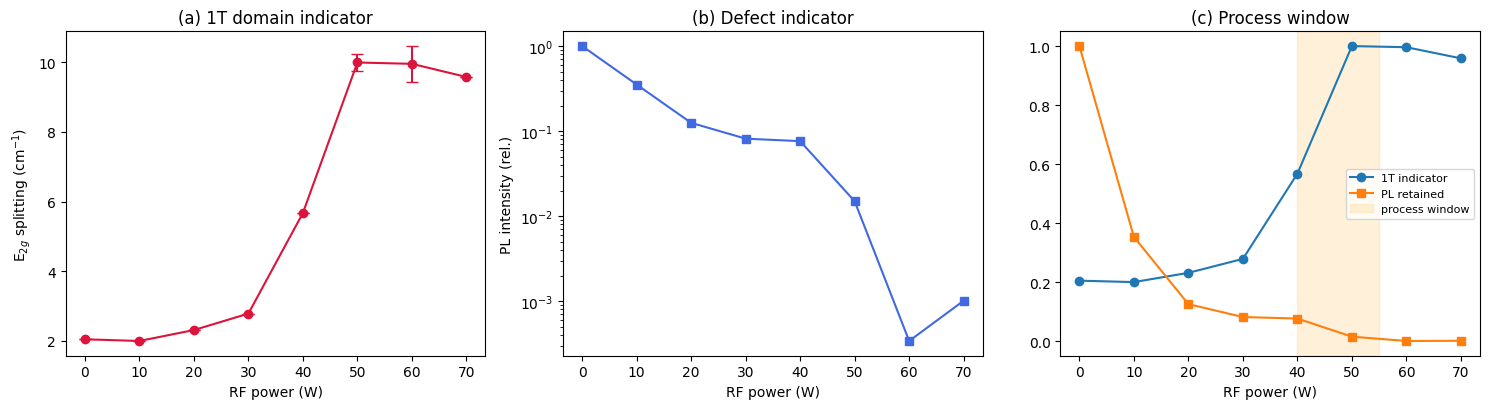

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].errorbar(merged.power_W, merged.E2g_split,
               yerr=merged.E2g_split_std.fillna(0),
               fmt='o-', color='crimson', capsize=4)
ax[0].set(xlabel='RF power (W)', ylabel='E$_{2g}$ splitting (cm$^{-1}$)',
          title='(a) 1T domain indicator')

ax[1].semilogy(merged.power_W, merged.PL_rel, 's-', color='royalblue')
ax[1].set(xlabel='RF power (W)', ylabel='PL intensity (rel.)',
          title='(b) Defect indicator')

ax[2].plot(merged.power_W, merged.E2g_split/merged.E2g_split.max(),
           'o-', label='1T indicator')
ax[2].plot(merged.power_W, merged.PL_rel, 's-', label='PL retained')
ax[2].axvspan(40, 55, color='orange', alpha=0.15, label='process window')
ax[2].set(xlabel='RF power (W)', title='(c) Process window')
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR + '/summary.png', dpi=150)
merged.to_csv(DATA_DIR + '/metrics.csv', index=False)
plt.show()

In [10]:
def si_normalize(f):
    a = np.loadtxt(f)
    x, y = a[:,0], a[:,1] - 500.0
    return x, y / y[(x>512)&(x<530)].max()

groups = {}
for f in glob.glob(DATA_DIR + '/*raman*.txt'):
    groups.setdefault(parse_power(f), []).append(f)

x0, _ = si_normalize(sorted(groups[0])[0])
J = (x0 > 130) & (x0 < 350)
pristine = si_normalize(sorted(groups[0])[0])[1]

print("파워  n   J1      J2      J3    검출한계(J/A1g)")
for pw in sorted(groups):
    specs = [si_normalize(f)[1] for f in sorted(groups[pw])]
    mean = np.mean(specs, axis=0)

    diff = (mean - pristine)[J]
    xs = x0[J]
    resid = diff - np.polyval(np.polyfit(xs, diff, 3), xs)
    noise = resid.std()

    sigmas = []
    for c in (155, 226, 325):
        w = (xs > c-8) & (xs < c+8)
        sigmas.append(resid[w].max()/noise if noise > 0 else 0)

    a1g = mean[(x0>400)&(x0<412)].max()
    base = mean[J] - np.polyval(np.polyfit(x0[J], mean[J], 3), x0[J])
    print(f"{pw:4d} {len(specs):2d}  {sigmas[0]:5.2f}σ {sigmas[1]:5.2f}σ {sigmas[2]:5.2f}σ   "
          f"{3*base.std()/a1g*100:.2f}%")

파워  n   J1      J2      J3    검출한계(J/A1g)
   0  1   0.00σ  0.00σ  0.00σ   1.38%
  10  1   2.36σ  2.65σ  2.12σ   1.54%
  20  1   1.45σ  2.35σ  1.84σ   1.74%
  30  1   0.58σ  2.77σ  2.45σ   1.90%
  40  1   1.39σ  2.41σ  1.54σ   1.98%
  50  2   0.82σ  1.44σ  1.79σ   2.53%
  60  3   1.03σ  2.20σ  2.38σ   3.49%
  70  1   0.85σ  2.20σ  2.51σ   3.44%


In [13]:
import glob, os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from google.colab import drive
drive.mount('/content/drive')

CVD_DIR = '/content/drive/MyDrive/mos2_cvd'
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

def parse_power(path):
    name = os.path.basename(path)
    name = re.sub(r'\.txt$', '', name)
    name = re.sub(r'(?i)mos2|al2o3|sio2', '', name)   # 화학식 숫자 제외
    m = re.search(r'(\d+)\s*[wW]', name)
    if m is None:
        raise ValueError(f"파워를 못 찾음: {os.path.basename(path)}")
    return int(m.group(1))

def lorentzian(x, amp, cen, wid):
    return amp * wid**2 / ((x - cen)**2 + wid**2)

def multi_lorentzian(x, *p):
    y = np.zeros_like(x)
    for i in range(0, len(p), 3):
        y += lorentzian(x, *p[i:i+3])
    return y

def local_baseline(xs, ys):
    e = max(3, len(xs)//25)
    x0, y0 = xs[:e].mean(), ys[:e].mean()
    x1, y1 = xs[-e:].mean(), ys[-e:].mean()
    return ys - (y0 + (y1-y0)*(xs-x0)/(x1-x0))

def fit_peaks(x, y, centers, window, wid0=3.5, tol=6.0, wmax=20.0):
    m = (x >= window[0]) & (x <= window[1])
    xs, ys = x[m], local_baseline(x[m], y[m])
    p0, lo, hi = [], [], []
    for c in centers:
        p0 += [max(ys.max()*0.3, 1.0), c, wid0]
        lo += [0.0, c-tol, 1.0]
        hi += [np.inf, c+tol, wmax]
    popt, _ = curve_fit(multi_lorentzian, xs, ys, p0=p0,
                        bounds=(lo, hi), maxfev=80000)
    peaks = [dict(amp=popt[i], cen=popt[i+1], wid=popt[i+2],
                  area=np.pi*popt[i]*popt[i+2]) for i in range(0, len(popt), 3)]
    return sorted(peaks, key=lambda d: d['cen'])

rows = []
for f in sorted(glob.glob(CVD_DIR + '/*raman*.txt'), key=parse_power):
    a = np.loadtxt(f)
    x, y = a[:,0], savgol_filter(a[:,1], 9, 3) - 500.0
    e2g_p, e2g_m, a1g = fit_peaks(x, y, [379, 386, 405], (358, 432))
    rows.append(dict(
        power_W   = parse_power(f),
        E2g_split = e2g_m['cen'] - e2g_p['cen'],
        A1g_cen   = a1g['cen'],
        sep       = a1g['cen'] - (e2g_p['cen'] + e2g_m['cen'])/2,
        A1g_FWHM  = 2*a1g['wid'],
        A1g_amp   = a1g['amp'],
        ratio     = a1g['area'] / (e2g_p['area'] + e2g_m['area']),
    ))
raman_all = pd.DataFrame(rows)
raman = raman_all.groupby('power_W').mean().reset_index()
raman['n']          = raman_all.groupby('power_W').size().values
raman['split_sd']   = raman_all.groupby('power_W')['E2g_split'].std().values
raman['A1g_cen_sd'] = raman_all.groupby('power_W')['A1g_cen'].std().values

rows = []
for f in sorted(glob.glob(CVD_DIR + '/*pl*.txt'), key=parse_power):
    a = np.loadtxt(f)
    x, y = a[:,0], savgol_filter(a[:,1], 31, 3)
    m = (x > 640) & (x < 720)
    xs, ys = x[m], local_baseline(x[m], y[m])
    rows.append(dict(power_W=parse_power(f), PL_area=trapz(ys, xs),
                     PL_lambda=xs[ys.argmax()]))
pl_all = pd.DataFrame(rows)
pl = pl_all.groupby('power_W').mean().reset_index()
pl['PL_rel'] = pl.PL_area / pl.PL_area.iloc[0]

cvd = raman.merge(pl, on='power_W')
cvd.to_csv(CVD_DIR + '/cvd_metrics.csv', index=False)
print(cvd[['power_W','n','E2g_split','split_sd','A1g_cen','A1g_cen_sd',
           'sep','A1g_FWHM','A1g_amp','PL_rel','PL_lambda']].round(3).to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 power_W  n  E2g_split  split_sd  A1g_cen  A1g_cen_sd    sep  A1g_FWHM  A1g_amp  PL_rel  PL_lambda
       0  1      1.833       NaN  404.711         NaN 20.074     7.307  122.498   1.000    680.885
      10  1      1.891       NaN  404.375         NaN 18.762     6.132   90.377   1.438    679.630
      30  1      1.883       NaN  405.616         NaN 21.332     5.992  149.220   0.553    687.576
      50  1      2.057       NaN  405.111         NaN 20.860     5.649  117.966   0.377    687.580
      70  1      3.605       NaN  404.768         NaN 23.412     6.852  105.712   0.231    687.338
      80  1      6.054       NaN  408.908         NaN 30.434    10.187   37.801   0.049    694.502
      90  4      6.705     1.342  409.057       2.274 31.228     8.094   42.133   0.015    688.289


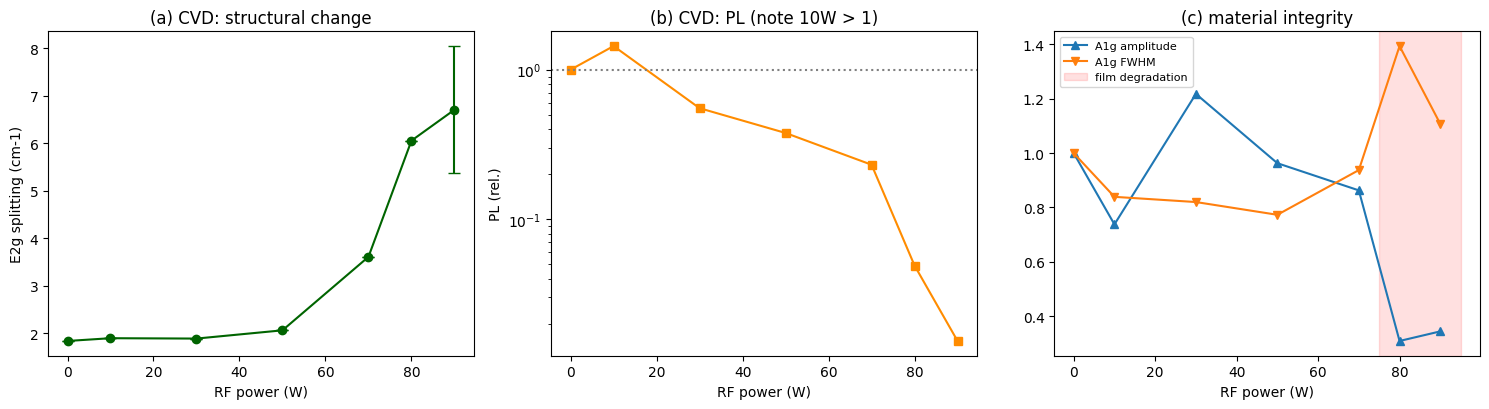

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].errorbar(cvd.power_W, cvd.E2g_split, yerr=cvd.split_sd.fillna(0),
               fmt='o-', color='darkgreen', capsize=4)
ax[0].set(xlabel='RF power (W)', ylabel='E2g splitting (cm-1)',
          title='(a) CVD: structural change')

ax[1].semilogy(cvd.power_W, cvd.PL_rel, 's-', color='darkorange')
ax[1].axhline(1.0, ls=':', c='gray')
ax[1].set(xlabel='RF power (W)', ylabel='PL (rel.)',
          title='(b) CVD: PL (note 10W > 1)')

ax[2].plot(cvd.power_W, cvd.A1g_amp/cvd.A1g_amp.iloc[0], '^-', label='A1g amplitude')
ax[2].plot(cvd.power_W, cvd.A1g_FWHM/cvd.A1g_FWHM.iloc[0], 'v-', label='A1g FWHM')
ax[2].axvspan(75, 95, color='red', alpha=0.12, label='film degradation')
ax[2].set(xlabel='RF power (W)', title='(c) material integrity')
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(CVD_DIR + '/cvd_summary.png', dpi=150)
plt.show()

In [20]:
import glob, os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

def parse_time(path):
    n = os.path.basename(path).replace('.txt','')
    n = re.sub(r'point[_ ]*\d+', '', n)          # 'point 2' 제거
    n = n.replace('O','0').replace('o','0')      # 알파벳 O -> 숫자 0
    n = re.sub(r'(?i)m0s2', '', n)               # 그 결과 생긴 m0s2 제거
    m = re.search(r'(\d+)\s*s', n)
    if m is None:
        raise ValueError(f"시간을 못 찾음: {os.path.basename(path)}")
    return int(m.group(1))

def lorentzian(x, amp, cen, wid):
    return amp * wid**2 / ((x - cen)**2 + wid**2)

def multi_lorentzian(x, *p):
    y = np.zeros_like(x)
    for i in range(0, len(p), 3):
        y += lorentzian(x, *p[i:i+3])
    return y

def local_baseline(xs, ys):
    e = max(3, len(xs)//25)
    x0, y0 = xs[:e].mean(), ys[:e].mean()
    x1, y1 = xs[-e:].mean(), ys[-e:].mean()
    return ys - (y0 + (y1-y0)*(xs-x0)/(x1-x0))

def fit_main(x, y):
    """E2g+, E2g-, A1g 3성분 피팅 (제약을 좁게 -> 피팅 폭주 방지)"""
    m = (x >= 368) & (x <= 425)
    xs, ys = x[m], local_baseline(x[m], y[m])
    p0 = [ys.max()*.4, 384, 3.5,  ys.max()*.4, 388, 3.5,  ys.max(), 407, 3.5]
    lo = [0, 376, 1.5,  0, 384, 1.5,  0, 402, 1.5]
    hi = [np.inf, 388, 12,  np.inf, 396, 12,  np.inf, 412, 12]
    po, _ = curve_fit(multi_lorentzian, xs, ys, p0=p0, bounds=(lo, hi), maxfev=80000)
    pk = sorted([dict(c=po[i+1], w=po[i+2], a=po[i], area=np.pi*po[i]*po[i+2])
                 for i in range(0, 9, 3)], key=lambda d: d['c'])
    return pk   # [E2g+, E2g-, A1g]

def has_si(x, y):
    """Si 520 피크 존재 여부 -> 기판 자동 판별"""
    return (y[(x>512)&(x<530)].max() - y[(x>545)&(x<565)].mean()) > 200

print("공통 함수 준비 완료")

공통 함수 준비 완료


In [21]:
def analyze_time_series(DIR, label):
    rows = []
    for f in sorted(glob.glob(DIR + '/*raman*.txt'), key=parse_time):
        a = np.loadtxt(f)
        x, y = a[:,0], savgol_filter(a[:,1], 9, 3) - 500.0
        e1, e2, a1 = fit_main(x, y)

        rec = dict(time_s=parse_time(f),
                   E2g_split=e2['c']-e1['c'],
                   E2g_cen=(e1['c']+e2['c'])/2,
                   A1g_cen=a1['c'],
                   sep=a1['c']-(e1['c']+e2['c'])/2,
                   A1g_FWHM=2*a1['w'],
                   A1g_amp=a1['a'])
        # 기판에 따라 정규화 방식 분기
        if has_si(x, y):
            si = local_baseline(x[(x>508)&(x<536)], y[(x>508)&(x<536)]).max()
            rec['A1g_norm'] = a1['a'] / si
            rec['substrate'] = 'SiO2'
        else:
            rec['A1g_norm'] = np.nan          # 사파이어는 표준 불안정 -> 사용 안 함
            rec['substrate'] = 'Al2O3'
        # J2 (1T 지표) — A1g 대비 높이 %
        m = (x>218) & (x<238)
        seg = y[m] - np.polyval(np.polyfit(x[m], y[m], 1), x[m])
        rec['J2_pct'] = seg.max() / a1['a'] * 100
        rows.append(rec)

    tr = pd.DataFrame(rows)
    tr_avg = tr.groupby('time_s').mean(numeric_only=True).reset_index()
    tr_avg['n'] = tr.groupby('time_s').size().values
    tr_avg['split_sd'] = tr.groupby('time_s')['E2g_split'].std().values

    rows = []
    for f in sorted(glob.glob(DIR + '/*pl*.txt'), key=parse_time):
        a = np.loadtxt(f)
        x, y = a[:,0], savgol_filter(a[:,1], 31, 3)
        m = (x > 640) & (x < 720)
        xs = x[m]
        ys = local_baseline(x[m], y[m])
        rows.append(dict(time_s=parse_time(f), PL_area=trapz(ys, xs),
                         PL_lambda=xs[ys.argmax()]))
    tp = pd.DataFrame(rows).groupby('time_s').mean().reset_index()
    tp['PL_rel'] = tp.PL_area / tp.PL_area.iloc[0]

    df = tr_avg.merge(tp, on='time_s')
    df['series'] = label
    print(f"\n=== {label}  (기판: {tr.substrate.iloc[0]}) ===")
    print(df[['time_s','n','E2g_split','split_sd','A1g_cen','sep',
              'J2_pct','PL_rel']].round(3).to_string(index=False))
    return df

DIR_A = '/content/drive/MyDrive/mos2_time_a'
DIR_B = '/content/drive/MyDrive/mos2_time_b'

timeA = analyze_time_series(DIR_A, 'time A (SiO2, 20W)')
timeB = analyze_time_series(DIR_B, 'time B (Al2O3, ?W)')


=== time A (SiO2, 20W)  (기판: SiO2) ===
 time_s  n  E2g_split  split_sd  A1g_cen    sep  J2_pct  PL_rel
      0  1      1.556       NaN  402.541 18.970   0.739   1.000
     20  1      2.038       NaN  403.552 20.571   1.052   0.611
     40  1      3.111       NaN  403.686 21.241   1.648   0.620
     60  1      4.931       NaN  404.079 22.544   1.942   0.156
     80  1      5.015       NaN  404.360 22.868   2.256   0.074
    100  1      7.414       NaN  405.846 25.020   2.695   0.070
    120  1      5.821       NaN  407.663 26.573   2.909   0.028
    140  1      6.805       NaN  410.299 29.635   7.773  -0.004

=== time B (Al2O3, ?W)  (기판: Al2O3) ===
 time_s  n  E2g_split  split_sd  A1g_cen    sep  J2_pct  PL_rel
      0  1      2.007       NaN  407.090 20.806   0.545   1.000
     10  1      1.969       NaN  407.941 22.030   0.585   0.278
     20  1      1.842       NaN  406.243 19.696   0.765   0.456
     30  1      5.783       NaN  406.805 23.477   0.610   0.174
     40  1      6.405  

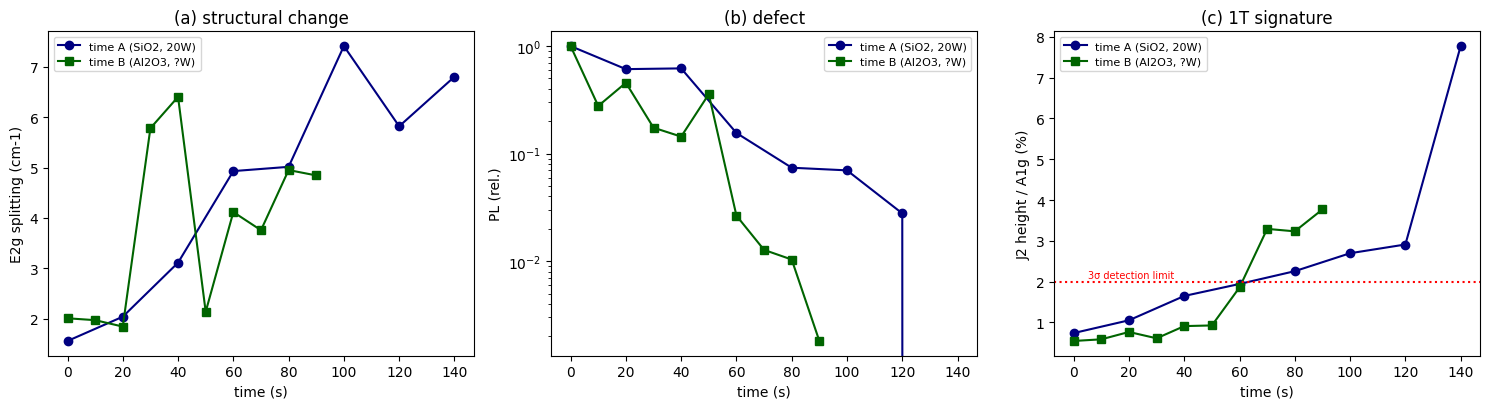

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

for df, c, mk in ((timeA, 'navy', 'o'), (timeB, 'darkgreen', 's')):
    lab = df.series.iloc[0]
    ax[0].plot(df.time_s, df.E2g_split, mk+'-', color=c, label=lab)
    ax[1].plot(df.time_s, df.PL_rel, mk+'-', color=c, label=lab)
    ax[2].plot(df.time_s, df.J2_pct, mk+'-', color=c, label=lab)

ax[0].set(xlabel='time (s)', ylabel='E2g splitting (cm-1)', title='(a) structural change')
ax[1].set(xlabel='time (s)', ylabel='PL (rel.)', title='(b) defect', yscale='log')
ax[2].set(xlabel='time (s)', ylabel='J2 height / A1g (%)', title='(c) 1T signature')
ax[2].axhline(2.0, ls=':', c='red')
ax[2].text(5, 2.1, '3σ detection limit', fontsize=7, color='red')
for a_ in ax: a_.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/time_comparison.png', dpi=150)
plt.show()

In [23]:
timeA.to_csv('/content/drive/MyDrive/time_a_metrics.csv', index=False)
timeB.to_csv('/content/drive/MyDrive/time_b_metrics.csv', index=False)

In [24]:
import glob, os
for d in ['/content/drive/MyDrive',
          '/content/drive/MyDrive/mos2',
          '/content/drive/MyDrive/mos2_cvd']:
    print(f"\n[{d}]")
    for f in sorted(glob.glob(d + '/*.csv') + glob.glob(d + '/*.png')):
        print("  ", os.path.basename(f))


[/content/drive/MyDrive]
   IMG_2561.png
   IMG_4346.png
   time_a_metrics.csv
   time_b_metrics.csv
   time_comparison.png

[/content/drive/MyDrive/mos2]
   11.04 si02 0W om.png
   11.04 si02 10W om.png
   11.04 si02 20W om.png
   11.04 si02 30W om.png
   11.04 si02 40W om.png
   11.04 si02 50W om.png
   11.04 si02 60W om.png
   11.04 si02 70W om.png
   metrics.csv
   summary.png

[/content/drive/MyDrive/mos2_cvd]
   MoS2 Al2O3 0w OM.png
   MoS2 Al2O3 10w OM.png
   MoS2 Al2O3 30w OM.png
   MoS2 Al2O3 50w OM.png
   MoS2 Al2O3 70w OM.png
   MoS2 Al2O3 80w OM.png
   MoS2 Al2O3 90w OM.png
   cvd_metrics.csv
   cvd_summary.png
